 Week 3 – Multi‑Source Data Pipeline

# This notebook demonstrates an end‑to‑end ETL pipeline integrating:
# 1. **Internal operational data** (cleaned CSV from Week 2)
# 2. **External weather API** (Open‑Meteo, free, no API key)
# 3. **Supplementary database** (holidays) using `sqlalchemy`

In [7]:
import pandas as pd
import numpy as np
import sqlite3
import requests
from datetime import datetime, timedelta
from sqlalchemy import create_engine, Column, String, Date, Integer, Float
from sqlalchemy.orm import declarative_base, sessionmaker
import warnings
warnings.filterwarnings('ignore')

# For visualisation
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported.")

Libraries imported.


Source 1 – Internal Operational Data
# 
# We load the **cleaned operational dataset** from the CSV file `clean_operational_events.csv` (provided).
# 
# Columns:
# - `record_id` – unique event ID
# - `event_timestamp_utc` – UTC timestamp
# - `depot_id`, `depot_name`, `region`, `product_code`
# - `pressure_psi`, `flow_rate_lpm`, `temperature_c`
# - `status` (`OK`, `WARNING`, `ERROR`)
# - `incident_flag`, `maintenance_required`, etc.
# 
# We convert the timestamp to datetime and extract the date for merging.

In [ ]:
# File name of the cleaned operational dataset
CSV_FILE = "clean_operational_events.csv"

# Load the CSV file
try:
    ops_df = pd.read_csv(CSV_FILE)
    print(f"Loaded {len(ops_df)} rows from {CSV_FILE}")
except FileNotFoundError:
    print(f"Error: {CSV_FILE} not found. Please ensure the file is in the same directory.")
    raise

# Convert timestamp to datetime and extract date
ops_df['event_timestamp_utc'] = pd.to_datetime(ops_df['event_timestamp_utc'], utc=True)
ops_df['event_date'] = ops_df['event_timestamp_utc'].dt.date

# Keep only relevant columns for the analysis
ops_cols = ['record_id', 'event_date', 'depot_id', 'depot_name', 'region', 
            'product_code', 'pressure_psi', 'flow_rate_lpm', 'temperature_c', 
            'incident_flag', 'maintenance_required']
ops_df = ops_df[ops_cols].copy()

print(f"Operational data shape: {ops_df.shape}")
ops_df.head()

Loaded 4000 rows from clean_operational_events.csv
Operational data shape: (4000, 11)


,record_id,event_date,depot_id,depot_name,region,product_code,pressure_psi,flow_rate_lpm,temperature_c,incident_flag,maintenance_required
0,OPS-00002,2026-03-01,DPT005,Nakuru Depot,Rift Valley,PMS,97.72,616.90,26.6,0,0
1,OPS-00003,2026-03-01,DPT002,Mombasa Terminal,Coast,JET-A1,74.48,1222.52,21.1,0,0
2,OPS-00004,2026-03-01,DPT001,Nairobi Terminal,Central,IK,49.22,508.40,18.6,0,0
3,OPS-00005,2026-03-01,DPT005,Nakuru Depot,Rift Valley,IK,73.03,535.83,34.6,0,0
4,OPS-00006,2026-03-01,DPT005,Nakuru Depot,Rift Valley,IK,133.24,994.28,19.6,0,0


 Source 2 – External Weather API
# 
# We use the **Open‑Meteo Archive API** (free, no API key) to fetch daily weather for Nairobi, Kenya.
# 
# Returns:
# - `temperature_2m_mean` – average daily temperature (°C)
# - `precipitation_sum` – total precipitation (mm)
# - `wind_speed_10m_max` – maximum wind speed (km/h)
# 
# We request data for the date range present in our operational events.
# 
# **Error handling**: if the API call fails, we print a warning and create an empty weather DataFrame; missing weather will be filled with `NaN` later.


In [9]:
# Determine date range from operational data
min_date = ops_df['event_date'].min()
max_date = ops_df['event_date'].max()
print(f"Fetching weather for dates from {min_date} to {max_date}")

# Open-Meteo API endpoint (archive data)
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": -1.286389,          # Nairobi
    "longitude": 36.817223,
    "start_date": min_date.strftime("%Y-%m-%d"),
    "end_date": max_date.strftime("%Y-%m-%d"),
    "daily": ["temperature_2m_mean", "precipitation_sum", "wind_speed_10m_max"],
    "timezone": "Africa/Nairobi"
}

try:
    resp = requests.get(WEATHER_URL, params=params, timeout=30)
    resp.raise_for_status()
    weather_json = resp.json()
    daily = weather_json['daily']
    weather_df = pd.DataFrame({
        'event_date': pd.to_datetime(daily['time']).date,
        'temp_mean_c': daily['temperature_2m_mean'],
        'precip_mm': daily['precipitation_sum'],
        'wind_max_kph': daily['wind_speed_10m_max']
    })
    print(f"Successfully fetched {len(weather_df)} days of weather data.")
except Exception as e:
    print(f"⚠️ Weather API failed: {e}")
    # Create empty DataFrame with expected columns; missing values will be filled with NaN later
    weather_df = pd.DataFrame(columns=['event_date', 'temp_mean_c', 'precip_mm', 'wind_max_kph'])
    print("Weather data will be missing in the merged dataset.")

weather_df.head()

Fetching weather for dates from 2026-03-01 to 2026-04-22
Successfully fetched 53 days of weather data.


,event_date,temp_mean_c,precip_mm,wind_max_kph
0,2026-03-01,18.5,8.9,12.5
1,2026-03-02,18.5,7.2,10.4
2,2026-03-03,19.0,6.6,12.9
3,2026-03-04,18.7,20.5,9.9
4,2026-03-05,18.5,15.7,11.8


 Source 3 – Supplementary Database (Holidays)
# 
# We create a small SQLite database using `sqlalchemy` with a `holidays` table containing Kenyan public holidays.
# 
# We then write **two SQL queries**:
# 1. A **join** that adds a `is_holiday` flag to each operational row.
# 2. A **summary query using `JOIN` and `GROUP BY`** that computes daily aggregates (average pressure, flow rate, temperature, event count, incidents, maintenance) grouped by `event_date` and `is_holiday`.
# 
# Both are loaded into DataFrames via `pd.read_sql`.

In [ ]:
# Define a list of Kenyan public holidays (2026 – sample)
holidays_data = [
    ('2026-01-01', "New Year's Day"),
    ('2026-05-01', 'Labour Day'),
    ('2026-06-01', 'Madaraka Day'),
    ('2026-10-10', 'Moi Day'),
    ('2026-10-20', 'Mashujaa Day'),
    ('2026-12-12', 'Jamhuri Day'),
    ('2026-12-25', 'Christmas Day'),
    ('2026-12-26', 'Boxing Day'),
]

holidays_df = pd.DataFrame(holidays_data, columns=['holiday_date', 'holiday_name'])
holidays_df['holiday_date'] = pd.to_datetime(holidays_df['holiday_date']).dt.date
print("Holidays to insert:")
holidays_df

# %%
# Create an SQLite engine (in-memory for speed, or we can persist)
engine = create_engine('sqlite:///supplementary.db', echo=False)
Base = declarative_base()

class Holiday(Base):
    __tablename__ = 'holidays'
    id = Column(Integer, primary_key=True)
    holiday_date = Column(Date, unique=True)
    holiday_name = Column(String)

# Create table
Base.metadata.create_all(engine)

# Insert holidays (avoid duplicates)
Session = sessionmaker(bind=engine)
session = Session()
for _, row in holidays_df.iterrows():
    existing = session.query(Holiday).filter_by(holiday_date=row['holiday_date']).first()
    if not existing:
        new_holiday = Holiday(holiday_date=row['holiday_date'], holiday_name=row['holiday_name'])
        session.add(new_holiday)
session.commit()
session.close()

print("Holidays table created and populated.")

# %%
# Write operational data to the same database as a temporary table 'events'
ops_for_sql = ops_df.copy()
ops_for_sql['event_date'] = pd.to_datetime(ops_for_sql['event_date']).dt.date
ops_for_sql.to_sql('events', engine, if_exists='replace', index=False)

# ----------------------------------------------------------------------
# QUERY 1: Join events with holidays to add a flag
# ----------------------------------------------------------------------
join_query = """
SELECT 
    e.record_id,
    e.event_date,
    e.depot_id,
    e.depot_name,
    e.region,
    e.product_code,
    e.pressure_psi,
    e.flow_rate_lpm,
    e.temperature_c,
    e.incident_flag,
    e.maintenance_required,
    CASE WHEN h.holiday_date IS NOT NULL THEN 1 ELSE 0 END AS is_holiday,
    h.holiday_name
FROM events e
LEFT JOIN holidays h ON e.event_date = h.holiday_date
"""

joined_df = pd.read_sql(join_query, engine)
print(f"Joined data shape: {joined_df.shape}")

# ----------------------------------------------------------------------
# QUERY 2: Summary with JOIN and GROUP BY
# ----------------------------------------------------------------------
summary_query = """
SELECT 
    e.event_date,
    CASE WHEN h.holiday_date IS NOT NULL THEN 1 ELSE 0 END AS is_holiday,
    COUNT(*) AS total_events,
    AVG(e.pressure_psi) AS avg_pressure_psi,
    AVG(e.flow_rate_lpm) AS avg_flow_rate_lpm,
    AVG(e.temperature_c) AS avg_temperature_c,
    SUM(e.incident_flag) AS incidents,
    SUM(e.maintenance_required) AS maintenance_required
FROM events e
LEFT JOIN holidays h ON e.event_date = h.holiday_date
GROUP BY e.event_date, is_holiday
ORDER BY e.event_date
"""

summary_df = pd.read_sql(summary_query, engine)
print(f"Summary data shape: {summary_df.shape}")
summary_df.head()

Holidays to insert:
Holidays table created and populated.
Joined data shape: (4000, 13)
Summary data shape: (53, 8)


,event_date,is_holiday,total_events,avg_pressure_psi,avg_flow_rate_lpm,avg_temperature_c,incidents,maintenance_required
0,2026-03-01,0,75,114.692267,898.100400,26.969333,4,8
1,2026-03-02,0,76,121.071579,903.933026,27.607895,3,8
2,2026-03-03,0,82,109.197927,901.288171,26.130488,3,10
3,2026-03-04,0,74,115.764459,887.612838,26.960811,9,8
4,2026-03-05,0,84,121.310357,884.710119,27.405952,3,11


Integration – Merge All Sources
# 
# We now have three DataFrames:
# - `joined_df`: row‑level data with holiday flag (Source 1 + flag from Source 3)
# - `summary_df`: daily aggregates by holiday status (Source 1 + Source 3, with GROUP BY)
# - `weather_df`: daily weather (Source 2)
# 
# We merge `joined_df` with `weather_df` on `event_date` (left join).  
# Then we merge the result with `summary_df` on `(event_date, is_holiday)` to add the aggregate columns to each row.
# 
# Missing weather values become `NaN`.

In [11]:
# Ensure date columns are date type (not datetime)
joined_df['event_date'] = pd.to_datetime(joined_df['event_date']).dt.date
weather_df['event_date'] = pd.to_datetime(weather_df['event_date']).dt.date
summary_df['event_date'] = pd.to_datetime(summary_df['event_date']).dt.date

# Merge weather (left join)
master_df = pd.merge(joined_df, weather_df, on='event_date', how='left')

# Merge summary aggregates (inner join, as every date should have a summary)
master_df = pd.merge(master_df, summary_df, on=['event_date', 'is_holiday'], how='left')

print(f"Master DataFrame shape: {master_df.shape}")
print("\nMissing weather values per column:")
print(master_df[['temp_mean_c', 'precip_mm', 'wind_max_kph']].isnull().sum())

master_df.head()

Master DataFrame shape: (4000, 22)

Missing weather values per column:
temp_mean_c     0
precip_mm       0
wind_max_kph    0
dtype: int64


,record_id,event_date,depot_id,depot_name,region,product_code,pressure_psi,flow_rate_lpm,temperature_c,incident_flag,...,holiday_name,temp_mean_c,precip_mm,wind_max_kph,total_events,avg_pressure_psi,avg_flow_rate_lpm,avg_temperature_c,incidents,maintenance_required_y
0,OPS-00002,2026-03-01,DPT005,Nakuru Depot,Rift Valley,PMS,97.72,616.90,26.6,0,...,None,18.5,8.9,12.5,75,114.692267,898.1004,26.969333,4,8
1,OPS-00003,2026-03-01,DPT002,Mombasa Terminal,Coast,JET-A1,74.48,1222.52,21.1,0,...,None,18.5,8.9,12.5,75,114.692267,898.1004,26.969333,4,8
2,OPS-00004,2026-03-01,DPT001,Nairobi Terminal,Central,IK,49.22,508.40,18.6,0,...,None,18.5,8.9,12.5,75,114.692267,898.1004,26.969333,4,8
3,OPS-00005,2026-03-01,DPT005,Nakuru Depot,Rift Valley,IK,73.03,535.83,34.6,0,...,None,18.5,8.9,12.5,75,114.692267,898.1004,26.969333,4,8
4,OPS-00006,2026-03-01,DPT005,Nakuru Depot,Rift Valley,IK,133.24,994.28,19.6,0,...,None,18.5,8.9,12.5,75,114.692267,898.1004,26.969333,4,8


 Analysis – Correlation
# 
# We investigate two questions:
# 1. **Does weather correlate with operational metrics?**  
#    Compute Pearson correlation between weather variables and pressure/flow rate.
# 2. **Do holidays affect pressure?**  
#    Compare average pressure on holidays vs. non‑holidays.
# 
# We also visualise the correlation matrix with a heatmap.

Correlation matrix:
               pressure_psi  flow_rate_lpm  temp_mean_c  precip_mm  \
pressure_psi       1.000000       0.004636     0.013736  -0.010261   
flow_rate_lpm      0.004636       1.000000     0.015752   0.007279   
temp_mean_c        0.013736       0.015752     1.000000  -0.533422   
precip_mm         -0.010261       0.007279    -0.533422   1.000000   
wind_max_kph      -0.001383      -0.033842     0.113223  -0.443979   

               wind_max_kph  
pressure_psi      -0.001383  
flow_rate_lpm     -0.033842  
temp_mean_c        0.113223  
precip_mm         -0.443979  
wind_max_kph       1.000000  

Average pressure on holidays (1) vs non-holidays (0):
is_holiday
0    115.196857
Name: pressure_psi, dtype: float64


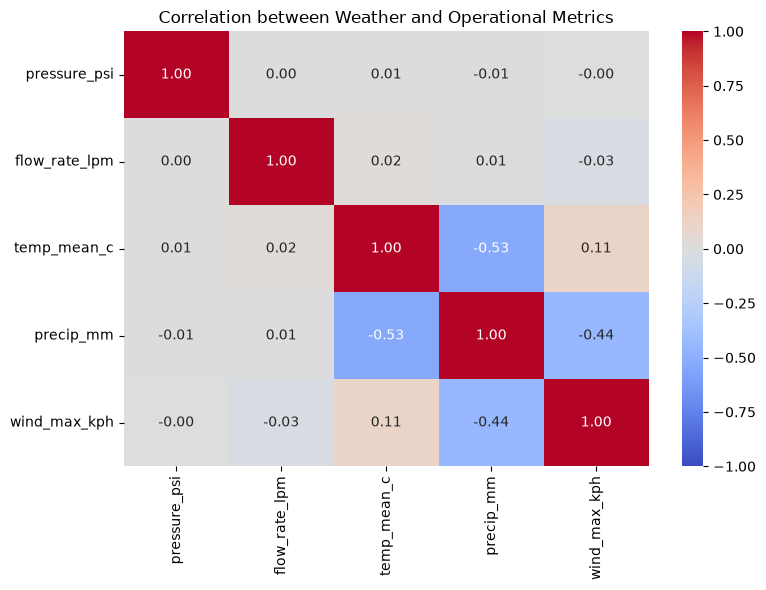

In [12]:
# Select numeric columns for correlation
numeric_cols = ['pressure_psi', 'flow_rate_lpm', 'temp_mean_c', 'precip_mm', 'wind_max_kph']
# Drop rows with missing weather (or we could impute)
corr_df = master_df[numeric_cols].dropna()
corr_matrix = corr_df.corr()
print("Correlation matrix:")
print(corr_matrix)

# Compare pressure on holidays vs non-holidays
holiday_avg = master_df.groupby('is_holiday')['pressure_psi'].mean()
print("\nAverage pressure on holidays (1) vs non-holidays (0):")
print(holiday_avg)

# %%
# Visualise correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation between Weather and Operational Metrics')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()